
=== AFT RESULTS TABLE ===
      Thermal_history        Model  ETCH_PIT_LENGTH AFT_source AFT_dataset  \
0  My Thermal History  Ketcham2007             1.65    dataset      Miller   

   AFT_age_Ma  Mean_track_length_um     Sigma  Central_age_Ma  Central_age_se  \
0        44.0             44.611011  0.505664          175.57            8.51   

   Pooled_age_Ma  Pooled_age_se      Chi2  
0         175.57           9.88  0.929213  


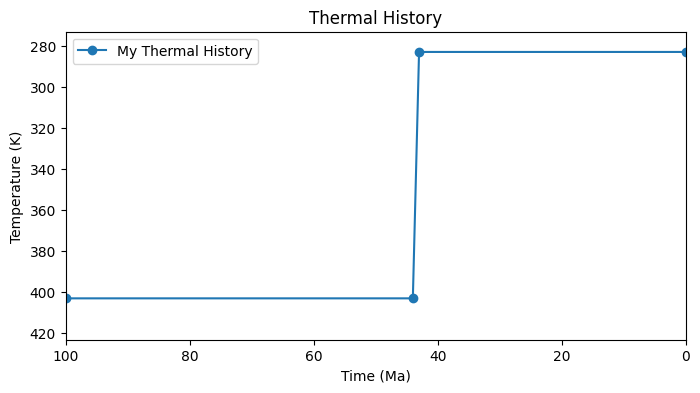

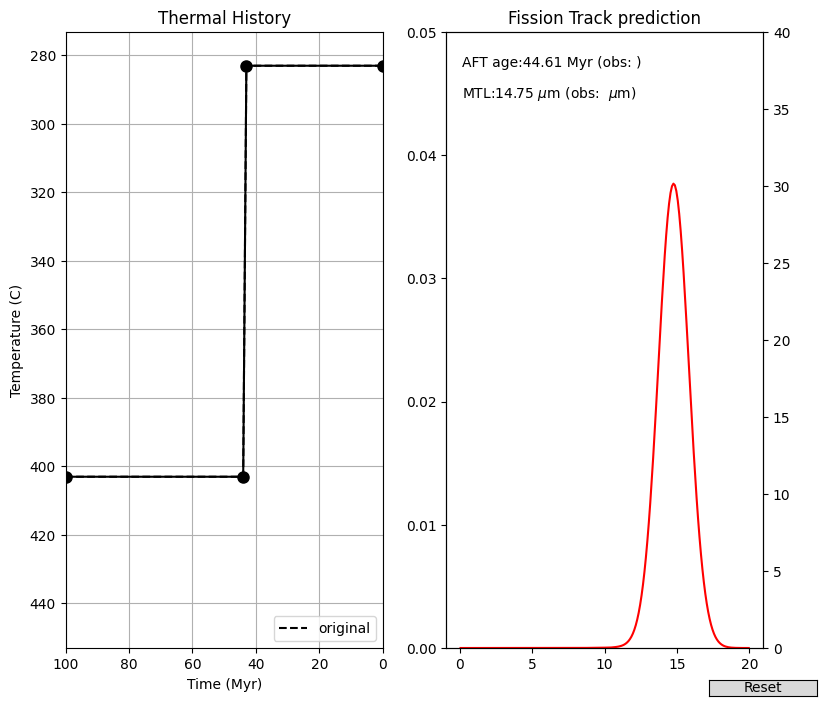

In [5]:
# ============================================================
# PYFTRACKS — MODULAR AFT FRAMEWORK
# Estrutura: CONFIG → BUILD → RUN → OUTPUT
# ============================================================

import sys
sys.path.append(r"H:\My Drive\PD\Projeto_PD_Annealing\04_SOFTWARE\pyFTracks-legacy")

import pyFTracks as FT
import matplotlib.pyplot as plt
import pandas as pd


# ============================================================
# 0) CONFIGURAÇÃO DO EXPERIMENTO (ÚNICO BLOCO A ALTERAR)
# ============================================================

CONFIG = {
    # ---- História térmica ----
    "thermal_history": {
        "name": "My Thermal History",
        "time": [0., 43., 44., 100.],
        "temperature": [283., 283., 403., 403.]
    },
    
    # ---- Modelo cinético ----
    "model": {
        "type": "Ketcham2007",   # opções: "Ketcham1999", "Ketcham2007"
        "ETCH_PIT_LENGTH": 1.65
    },
    
    # ---- Dados AFT (ζ-method) ----
    "aft_data": {
        "source": "dataset",     
        "dataset_name": "Miller",

        "manual": {
            "Ns": [31, 19, 56, 67, 88, 6, 18, 40, 36, 54, 35, 52, 51, 47, 27, 36, 64, 68, 61, 30],
            "Ni": [41, 22, 63, 71, 90, 7, 14, 41, 49, 79, 52, 76, 74, 66, 39, 44, 86, 90, 91, 41],
            "zeta": 350.,
            "zeta_err": 10./350.,
            "rhod": 1.304,
            "Nd": 2936
        }
    }
}

from pyFTracks import ressources

def load_aft_data(cfg):
    if cfg["source"] == "dataset":
        name = cfg["dataset_name"]
        dataset = getattr(ressources, name)

        # fallback físico: se dataset não tiver zeta_err, usa o valor do CONFIG manual
        zeta_err = getattr(dataset, "zeta_err", None)
        if zeta_err is None:
            zeta_err = cfg["manual"]["zeta_err"]

        return {
            "Ns": dataset.Ns,
            "Ni": dataset.Ni,
            "zeta": dataset.zeta,
            "zeta_err": zeta_err,
            "rhod": dataset.rhod,
            "Nd": dataset.nd
        }

    elif cfg["source"] == "manual":
        return cfg["manual"]

    else:
        raise ValueError("aft_data.source deve ser 'dataset' ou 'manual'")


# ============================================================
# 1) BUILD — História térmica
# ============================================================

def build_thermal_history(cfg):
    return FT.ThermalHistory(
        name=cfg["name"],
        time=cfg["time"],
        temperature=cfg["temperature"]
    )

thermal_history = build_thermal_history(CONFIG["thermal_history"])


# ============================================================
# 2) BUILD — Modelo cinético
# ============================================================

def build_model(cfg, thermal_history):
    model_type = cfg["type"]
    params = {"ETCH_PIT_LENGTH": cfg["ETCH_PIT_LENGTH"]}
    
    if model_type == "Ketcham1999":
        model = FT.Ketcham1999(kinetic_parameters=params)
    elif model_type == "Ketcham2007":
        model = FT.Ketcham2007(kinetic_parameters=params)
    else:
        raise ValueError(f"Modelo não suportado: {model_type}")
    
    model.history = thermal_history
    return model

annealing_model = build_model(CONFIG["model"], thermal_history)


# ============================================================
# 3) RUN — Forward modelling AFT
# ============================================================

aft_age, mtl, sigma = annealing_model.calculate_age()


# ============================================================
# 4) RUN — Estatística AFT (ζ-method)
# ============================================================

def run_aft_statistics(cfg):
    Ns = cfg["Ns"]
    Ni = cfg["Ni"]
    zeta = cfg["zeta"]
    zeta_err = cfg["zeta_err"]
    rhod = cfg["rhod"]
    Nd = cfg["Nd"]
    
    central = FT.central_age(Ns, Ni, zeta, zeta_err, rhod, Nd)
    pooled = FT.pooled_age(Ns, Ni, zeta, zeta_err, rhod, Nd)
    single = FT.single_grain_ages(Ns, Ni, zeta, zeta_err, rhod, Nd)
    chi2 = FT.chi2_test(Ns, Ni)
    
    return central, pooled, single, chi2

aft_cfg = load_aft_data(CONFIG["aft_data"])
central_age, pooled_age, single_grain, chi2 = run_aft_statistics(aft_cfg)


# ============================================================
# 5) OUTPUT — Tabela de resultados
# ============================================================

def build_results_table():
    aft_source = CONFIG["aft_data"]["source"]
    aft_name = CONFIG["aft_data"]["dataset_name"] if aft_source == "dataset" else "manual"

    return pd.DataFrame({
        "Thermal_history": [CONFIG["thermal_history"]["name"]],
        "Model": [CONFIG["model"]["type"]],
        "ETCH_PIT_LENGTH": [CONFIG["model"]["ETCH_PIT_LENGTH"]],
        "AFT_source": [aft_source],
        "AFT_dataset": [aft_name],
        "AFT_age_Ma": [aft_age],
        "Mean_track_length_um": [mtl],
        "Sigma": [sigma],
        "Central_age_Ma": [central_age["Central"]],
        "Central_age_se": [central_age["se"]],
        "Pooled_age_Ma": [pooled_age["Pooled Age"]],
        "Pooled_age_se": [pooled_age["se"]],
        "Chi2": [chi2]
    })
df_results = build_results_table()
print("\n=== AFT RESULTS TABLE ===")
print(df_results)


# ============================================================
# 6) OUTPUT — Gráficos
# ============================================================

# História térmica
plt.figure(figsize=(8, 4))
plt.plot(thermal_history.input_time, thermal_history.input_temperature,
         label=thermal_history.name, marker="o")
plt.xlim(100., 0.)
plt.ylim(150. + 273.15, 0. + 273.15)
plt.ylabel("Temperature (K)")
plt.xlabel("Time (Ma)")
plt.legend()
plt.title("Thermal History")
plt.show()

# Viewer do pyFTracks
FT.Viewer(history=thermal_history, annealing_model=annealing_model)


In [4]:
from pyFTracks.ressources import Miller

print(type(Miller))
print(dir(Miller))
print("Ns:", Miller.Ns)
print("Ni:", Miller.Ni)

print("zeta:", getattr(Miller, "zeta", None))
print("zeta_err:", getattr(Miller, "zeta_err", None))
print("zeta_error:", getattr(Miller, "zeta_error", None))

print("rhod:", getattr(Miller, "rhod", None))
print("nd:", getattr(Miller, "nd", None))
print("Nd:", getattr(Miller, "Nd", None))



<class 'pyFTracks.structures.Sample'>
['A', 'Ni', 'Ns', 'T', '_AXIS_LEN', '_AXIS_ORDERS', '_AXIS_TO_AXIS_NUMBER', '_HANDLED_TYPES', '__abs__', '__add__', '__and__', '__annotations__', '__array__', '__array_priority__', '__array_ufunc__', '__bool__', '__class__', '__contains__', '__copy__', '__dataframe__', '__deepcopy__', '__delattr__', '__delitem__', '__dict__', '__dir__', '__divmod__', '__doc__', '__eq__', '__finalize__', '__floordiv__', '__format__', '__ge__', '__getattr__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__iadd__', '__iand__', '__ifloordiv__', '__imod__', '__imul__', '__init__', '__init_subclass__', '__invert__', '__ior__', '__ipow__', '__isub__', '__iter__', '__itruediv__', '__ixor__', '__le__', '__len__', '__lt__', '__matmul__', '__mod__', '__module__', '__mul__', '__ne__', '__neg__', '__new__', '__nonzero__', '__or__', '__pos__', '__pow__', '__radd__', '__rand__', '__rdivmod__', '__reduce__', '__reduce_ex__', '__repr__', '__rfloordiv__'